<a href="https://colab.research.google.com/github/yee23456/ML/blob/main/110_%E9%97%96%E9%97%9C/110ML%E9%AB%98%E9%9A%8E%E4%BA%94_B10805025_%E6%B2%88%E7%9D%BF%E6%9C%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

In [ ]:
df=pd.read_excel('/content/drive/MyDrive/大學/大數據資料/宜蘭生活機能.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   988 non-null    int64  
 1   CODE2        988 non-null    object 
 2   Total_secu   988 non-null    int64  
 3   Total_traf   988 non-null    int64  
 4   Total_phar   988 non-null    int64  
 5   Total_clin   988 non-null    int64  
 6   Total_bus    988 non-null    int64  
 7   Total_scho   988 non-null    int64  
 8   Proportion   988 non-null    float64
 9   Proporti_1   988 non-null    float64
 10  Proporti_2   988 non-null    float64
 11  fire index   988 non-null    float64
 12  unemployme   988 non-null    float64
 13  Total_cvs    988 non-null    int64  
 14  total_host   988 non-null    int64  
 15  total_trai   988 non-null    int64  
 16  Total_Price  988 non-null    int64  
 17  Unit_Price   987 non-null    float64
dtypes: float64(6), int64(11), object(1)
memory usage: 

In [ ]:
df.head()

,Unnamed: 0,CODE2,Total_secu,Total_traf,Total_phar,Total_clin,Total_bus,Total_scho,Proportion,Proporti_1,Proporti_2,fire index,unemployme,Total_cvs,total_host,total_trai,Total_Price,Unit_Price
0,0,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,18600000,57162.0
1,1,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,15260000,69971.0
2,2,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,6080000,25682.0
3,3,A0209-10,1,2,2,3,20,0,0.002385,0.025003,0.400048,0.357143,3.8,3,0,0,10500000,37808.0
4,4,A0209-10,1,2,2,3,20,0,0.002385,0.025003,0.400048,0.357143,3.8,3,0,0,10250000,36478.0


In [ ]:
X=df.drop(['Unnamed: 0', 'CODE2','Total_Price','Unit_Price'] , axis=1) #輸入自變數/特徵
from sklearn.model_selection import train_test_split #區分訓練集與測試集
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4)
kmeans.fit(X)
df['cluster'] = kmeans.predict(X)
df.drop(['Unnamed: 0', 'CODE2','Total_Price','Unit_Price'] , axis=1).columns
df.head()
# y_kmeans

,Unnamed: 0,CODE2,Total_secu,Total_traf,Total_phar,Total_clin,Total_bus,Total_scho,Proportion,Proporti_1,Proporti_2,fire index,unemployme,Total_cvs,total_host,total_trai,Total_Price,Unit_Price,cluster
0,0,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,18600000,57162.0,1
1,1,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,15260000,69971.0,1
2,2,A0205-02,0,10,1,0,42,0,0.002497,0.009939,0.149088,0.344828,3.8,3,0,1,6080000,25682.0,1
3,3,A0209-10,1,2,2,3,20,0,0.002385,0.025003,0.400048,0.357143,3.8,3,0,0,10500000,37808.0,0
4,4,A0209-10,1,2,2,3,20,0,0.002385,0.025003,0.400048,0.357143,3.8,3,0,0,10250000,36478.0,0


In [ ]:
df.groupby('cluster').mean()[df.drop(['Unnamed: 0', 'CODE2','Total_Price','Unit_Price','cluster'] , axis=1).columns]

,Total_secu,Total_traf,Total_phar,Total_clin,Total_bus,Total_scho,Proportion,Proporti_1,Proporti_2,fire index,unemployme,Total_cvs,total_host,total_trai
cluster,,,,,,,,,,,,,,
0,1.014493,3.049275,0.513043,1.173913,20.863768,1.223188,0.003725,0.025878,0.841762,0.387556,3.8,1.176812,0.026087,0.078261
1,1.877551,6.683673,0.051020,0.173469,49.418367,0.887755,0.001625,0.013747,0.159588,0.399775,3.8,1.540816,0.387755,0.030612
2,0.766082,3.824561,0.327485,0.666667,7.874269,1.476608,0.005679,0.035082,1.542980,0.392359,3.8,0.818713,0.000000,0.035088
3,0.921182,7.201970,0.866995,1.054187,31.349754,1.502463,0.004733,0.015130,0.548861,0.398232,3.8,2.354680,0.108374,0.103448


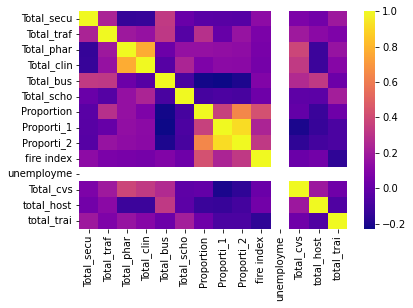

In [ ]:
sns.heatmap(df.iloc[:,1:].drop(columns=['CODE2','Total_Price','Unit_Price','cluster']).corr(),annot=False,cmap='plasma')

# K-means & 降維



In [ ]:
X=df.drop(['Unnamed: 0', 'CODE2','Total_Price','Unit_Price','cluster'] , axis=1)
R=np.corrcoef(X.T)
u, s, vh = np.linalg.svd(R, full_matrices=True)#Singular Value Decomposition.
s

array([2.77872507, 2.20406468, 1.81557098, 1.25585412, 1.        ,
       0.99144392, 0.87217394, 0.8062665 , 0.71123202, 0.5772058 ,
       0.4532092 , 0.30193374, 0.2110515 , 0.02126855])

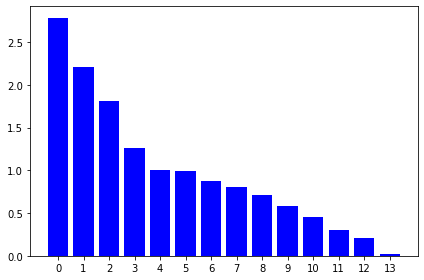

In [ ]:
factors=[i for i in range(len(s))]
plt.bar(factors, s, color='blue')
plt.xticks(factors)
plt.tight_layout()

In [ ]:
X_std = StandardScaler().fit_transform(X)#標準縮放器
FA = FactorAnalysis(n_components=5,rotation="varimax",random_state=0)
FA_1=FA.fit(X_std)
Aij=FA_1.components_
X_std[0]

array([ 0.41020784, -0.22676384, -0.49932205,  0.97414499,  1.51561804])

In [ ]:
X_Fscore = FA.fit_transform(X_std)
X_Fscore=X_Fscore*(-1)
X_Fscore_frame = pd.DataFrame(X_Fscore, columns=['fa_1','fa_2','fa_3','fa_4','fa_5']) 
X_Fscore_frame

,fa_1,fa_2,fa_3,fa_4,fa_5
0,0.407681,-0.225202,-0.481846,0.885162,1.249487
1,0.407681,-0.225202,-0.481846,0.885162,1.249487
2,0.407681,-0.225202,-0.481846,0.885162,1.249487
3,0.120224,-0.491336,-1.521825,-0.019473,-0.165529
4,0.120224,-0.491336,-1.521825,-0.019473,-0.165529
...,...,...,...,...,...
983,0.760222,1.462687,-2.177217,-0.210311,0.239373
984,0.760222,1.462687,-2.177217,-0.210311,0.239373
985,0.760222,1.462687,-2.177217,-0.210311,0.239373
986,0.760222,1.462687,-2.177217,-0.210311,0.239373


In [ ]:
X=X_Fscore_frame[['fa_1','fa_2','fa_3','fa_4','fa_5']] #輸入自變數/特徵

In [ ]:
from sklearn.cluster import KMeans
KM=KMeans(n_clusters=5,init='random',random_state=5)
KM.fit(X)
# KM.predict(X)

KMeans(init='random', n_clusters=5, random_state=5)

In [ ]:
pd.DataFrame(KM.transform(X)[:10],columns=['特徵0','特徵1','特徵2','特徵3','特徵4']).style.highlight_min(axis=1,color='red') 

,特徵0,特徵1,特徵2,特徵3,特徵4
0,3.051651,2.644671,1.714803,5.402789,2.302089
1,3.051651,2.644671,1.714803,5.402789,2.302089
2,3.051651,2.644671,1.714803,5.402789,2.302089
3,3.307991,1.474957,1.786608,4.998256,2.268754
4,3.307991,1.474957,1.786608,4.998256,2.268754
5,3.307991,1.474957,1.786608,4.998256,2.268754
6,3.307991,1.474957,1.786608,4.998256,2.268754
7,3.307991,1.474957,1.786608,4.998256,2.268754
8,3.307991,1.474957,1.786608,4.998256,2.268754
9,3.307991,1.474957,1.786608,4.998256,2.268754
